['S5', 'S6']
[13, 15]
[['R0', 'S0', 'S6'], ['R0', 'S1', 'S6'], ['R0', 'S2', 'S6'], ['R0', 'S3', 'S6'], ['R0', 'S4', 'S6']]
5
['R0+S0s -> R0+S0', 'R0+S1s -> R0+S1', 'R0+S2s -> R0+S2', 'R0+S3s -> R0+S3', 'R0+S4s -> R0+S4', 'R1+S0s -> R1+S0', 'R1+S1s -> R1+S1', 'R1+S2s -> R1+S2', 'R1+S3s -> R1+S3', 'R1+S4s -> R1+S4', 'S0+S5s -> S0+S5', 'S0+S6s -> S0+S6', 'S1+S5s -> S1+S5', 'S1+S6s -> S1+S6', 'S2+S5s -> S2+S5', 'S2+S6s -> S2+S6', 'S3+S5s -> S3+S5', 'S3+S6s -> S3+S6', 'S4+S5s -> S4+S5', 'S4+S6s -> S4+S6', 'S0s -> S0', 'S1s -> S1', 'S2s -> S2', 'S3s -> S3', 'S4s -> S4', 'S5s -> S5', 'S6s -> S6']
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.

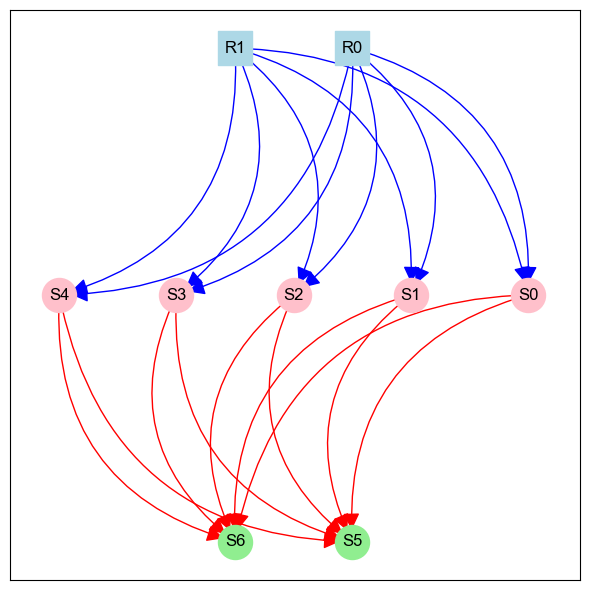

In [1]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random
from sympy import Poly, Symbol

from scipy.integrate import solve_ivp
from functools import partial
import time

# --- Example usage with new class structure ---
seed = 52
np.random.seed(seed)
random.seed(seed)

NR = 2

NS_vec = [5,2]
NS = sum(NS_vec)
p_f = 0.75
p_r = 0
input_nodes = [f'R{i}' for i in range(NR)]
target_nodes = [f'S{NS-2}', f'S{NS-1}']
print(target_nodes)

# species_names, reaction_strings, L, input_indices = generate_random_signaling_network(NR, NL, NL_in, prob, include_reverse=True, include_uncatalyzed=True)

#species_names, reaction_strings, L, adjacency_matrix, input_substrates = generate_dag_signaling_network(NR, NS, p_f, p_r, include_reverse=True, include_uncatalyzed=True)
species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)

target_node_idxs = [species_names.index(node) for node in target_nodes]
print(target_node_idxs)
visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, num_outs=NS_vec[-1])
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')
print(n_paths)
print(len(n_paths))
#print(input_indices)
print(reaction_strings)

# n_nodes = 3
# NS = 1
# prob = 1
# extra_reactions = ['A+B -> C+C']
# input_reactions_list = [['R0+A -> R0+B']]
# species_names, reaction_strings, L = generate_random_first_order_network(n_nodes, input_reactions_list, prob, extra_reactions = extra_reactions, include_reverse=False)
# #visualize_dag_signaling_network(adjacency_matrix, input_substrates, NR, NS)

print(L)
print(reaction_strings)

# NR = 1
# NL_vec = [2,2]
# species_names, reaction_strings, L = generate_feedforward_signaling_network(NR, NL_vec)

r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=42,
    species_names=species_names,
    force_reverse=True
)

# 1. Create the simulator
sim = ReactionNetworkSimulator(r_n)

print("Complexes per class:", r_n.complexes_per_class)
print("Reactions per class:", r_n.reactions_per_class)
print("Extra conservations", r_n.n_species - np.linalg.matrix_rank(r_n.Y @ r_n.A) - r_n.n_cons)

for i, node_assignment in enumerate(r_n.assignments):
    print(f"Linkage group {i+1}: {node_assignment}")

# symbolic ODEs
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()


cycles = compute_cycles(r_n)

# # Visualize linkage classes
# sz = 3
# fig, axes = plt.subplots(1, len(r_n.linkage_groups), figsize=(sz*len(r_n.linkage_groups), sz))

# if len(r_n.linkage_groups) == 1:
#     pos = nx.spring_layout(r_n.linkage_groups[0])
#     nx.draw(r_n.linkage_groups[0], pos=pos, with_labels=True, ax=axes, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
#     axes.set_title("Linkage class 1")
# else:
#     for i, (G, ax) in enumerate(zip(r_n.linkage_groups, axes)):
#         pos = nx.spring_layout(G)
#         nx.draw(G, pos=pos, with_labels=True, ax=ax, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
#         ax.set_title(f"Linkage class {i+1}")
# plt.tight_layout()
# plt.show()

# 2. Reduce the ODE system using conservation laws
sim.solve_conservation_laws()
print("Remaining species after reduction:", sim.remaining_species)
print("Conservation constants (symbols):", sim.const_syms)
print("Eliminated species solutions:", sim.elimination_solutions)



rates_orig = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])


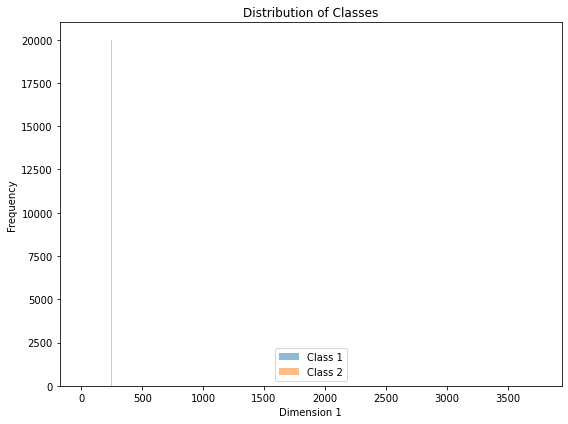

In [15]:
############################################################
################  Load classification data #################
############################################################

n_classes = 2

from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler

data_type = "gaussians"
n_samples = 20000

if data_type == "gaussian":
######  Gaussian example
    
    input_dim = 1
    scale = 5

    mu_1 = scale*7.5e0 * np.ones(input_dim)
    cov_1 = scale**1 * 0.02 * np.diag(np.ones(input_dim))
    dist_1 = np.abs(np.random.multivariate_normal(mu_1, cov_1, n_samples))

    mu_2 = scale*1e0 * np.ones(input_dim)
    cov_2 = scale**1 *0.02 * np.diag(np.ones(input_dim))
    dist_2 = np.abs(np.random.multivariate_normal(mu_2, cov_2, n_samples))

    data_list = [[dat for dat in dist_1], [dat for dat in dist_2]]

elif data_type == "gaussians":
######  Gaussian example
    
    input_dim = 1
    scale = 5

    mu_1a = scale*2.5e0 * np.ones(input_dim)
    mu_1b = scale*7.5e2 * np.ones(input_dim)

    cov_1 = scale**1 * 0.02 * np.diag(np.ones(input_dim))
    dist_1a = np.abs(np.random.multivariate_normal(mu_1a, cov_1, int(n_samples)))
    dist_1b = np.abs(np.random.multivariate_normal(mu_1b, cov_1, int(n_samples)))
    dist_1 = np.concatenate([dist_1a, dist_1b], axis=0)

    mu_2 = scale*5e1 * np.ones(input_dim)

    cov_2 = scale**1 *0.02 * np.diag(np.ones(input_dim))
    dist_2 = np.abs(np.random.multivariate_normal(mu_2, cov_2, n_samples))

    data_list = [[dat for dat in dist_1], [dat for dat in dist_2]]

elif data_type == "moons":
    # Convert sklearn noisy_moons to same format as data_list,
    # allowing user to specify scale and offset
    noisy_moons_X, noisy_moons_y = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=170)

    # Specify the desired scale and offset here
    noisy_moons_scale = 10.0    # Change to your desired scale
    noisy_moons_offset = noisy_moons_scale * np.array([2.0, 2.0])  # Change for desired offset; must have shape (2,)

    # Apply scale and offset
    noisy_moons_X = noisy_moons_X * noisy_moons_scale + noisy_moons_offset
    data_list = [[dat for dat in noisy_moons_X[noisy_moons_y == i]] for i in range(2)]

elif data_type == "circle_vs_square":
    # Sample uniformly from square [0, 2*x_c] x [0, 2*x_c]
    # Class 0: Points inside circle centered at (x_c, x_c) with radius r
    # Class 1: Points outside the circle
    scale = 1
    offset = scale * 0.0
    x_c = scale * 5.0 + offset     # center coordinate
    r = scale * 3.0         # radius of circle
    
    dist_circle = []  # class 0: inside circle
    dist_square = []  # class 1: outside circle
    
    for _ in range(n_samples):
        # Sample uniformly from square [0, 2*x_c] x [0, 2*x_c]
        x = np.random.uniform(0, 2 * (x_c - offset)) + offset
        y = np.random.uniform(0, 2 * (x_c - offset)) + offset
        
        # Check if point is inside circle
        dist_from_center = np.sqrt((x - x_c)**2 + (y - x_c)**2)
        
        if dist_from_center <= r:
            dist_circle.append(np.array([x, y]))
        else:
            dist_square.append(np.array([x, y]))
    
    data_list = [dist_circle, dist_square]

elif data_type == "diagonal_cut":
    # Classify according to which side of the diagonal y = x the point is on
    # Class 0: y > x; Class 1: y <= x
    scale = 0.2
    offset = scale * 2.0
    x_c = scale * 5.0 + offset  # to keep square region similar to above
    dist_above = []   # class 0: y > x
    dist_below = []   # class 1: y <= x

    for _ in range(n_samples):
        x = np.random.uniform(0, 2 * (x_c - offset)) + offset
        y = np.random.uniform(0, 2 * (x_c - offset)) + offset

        if y > x:
            dist_above.append(np.array([x, y]))
        else:
            dist_below.append(np.array([x, y]))
    
    data_list = [dist_above, dist_below]

elif data_type == "bottom_quarter_intersect":
    # Class 0: Points in the bottom quarter region defined by the intersection of y = x and y = 1 - x
    # inside the square [0, 1] x [0, 1], then apply scale and offset
    # Class 1: All other points inside the [0, 1] x [0, 1] square, excluding class 0.
    # That region is the triangle below both lines: y <= x AND y <= 1 - x. This triangle's vertices are: (0,0), (0.5,0), (1,0)
    dist_bottom_quarter = []  # class 0
    dist_other = []           # class 1
    
    scale = 10
    offset = scale * 0.0

    for _ in range(n_samples):
        # generate point in [0,1]x[0,1]
        x = np.random.uniform(0, 1)
        y = np.random.uniform(0, 1)

        # Triangle: y <= x AND y <= 1-x
        if y <= x and y <= 1 - x:
            # Apply scale and offset before adding
            p = np.array([x, y]) * scale + offset
            dist_bottom_quarter.append(p)
        else:
            p = np.array([x, y]) * scale + offset
            dist_other.append(p)

    data_list = [dist_bottom_quarter, dist_other]


input_data = InputData(n_classes, data_list)

# Redefine dist_1 and dist_2 from data_list for legacy code compatibility, but now as np.arrays
dist_1 = np.vstack(data_list[0])
dist_2 = np.vstack(data_list[1])

plt.figure(figsize=(8, 6))
if dist_1.shape[1] == 1:
    # Use fixed-width bins based on the min/max over both classes
    all_x = np.concatenate([dist_1[:, 0], dist_2[:, 0]])
    bin_width = 5  # Set desired bin width here
    bins = np.arange(np.min(all_x), np.max(all_x) + bin_width, bin_width)
    plt.hist(dist_1[:, 0], bins=bins, alpha=0.5, label='Class 1')
    plt.hist(dist_2[:, 0], bins=bins, alpha=0.5, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Frequency')
elif dist_1.shape[1] == 2:
    plt.scatter(dist_1[:, 0], dist_1[:, 1], alpha=0.3, s=1, label='Class 1')
    plt.scatter(dist_2[:, 0], dist_2[:, 1], alpha=0.3, s=1, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
else:
    # More than 2 dimensions: project to first two
    plt.scatter(dist_1[:, 0], dist_1[:, 1], alpha=0.3, s=1, label='Class 1')
    plt.scatter(dist_2[:, 0], dist_2[:, 1], alpha=0.3, s=1, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
plt.title('Distribution of Classes')
plt.legend()
plt.tight_layout()
plt.show()



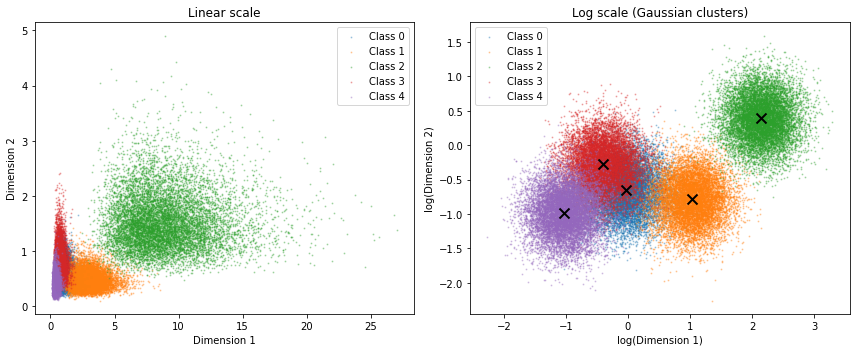

In [16]:
import numpy as np

def generate_lognormal_mixture(
    n_classes: int,
    n_samples_per_class: int,
    input_dim: int,
    log_means: list,
    log_variances: list,
    random_state: int = None
):
    if random_state is not None:
        np.random.seed(random_state)
    
    data_list = []
    for c in range(n_classes):
        mu = np.array(log_means[c]).flatten()
        var = log_variances[c]
        if np.isscalar(var):
            cov = var * np.eye(input_dim)
        else:
            cov = np.diag(np.array(var).flatten())
        
        log_samples = np.random.multivariate_normal(mu, cov, n_samples_per_class)
        samples = np.exp(log_samples)
        data_list.append([sample for sample in samples])
    
    return n_classes, data_list


def generate_lognormal_mixture_random_centers(
    n_classes: int,
    n_samples_per_class: int,
    input_dim: int = 1,
    center_variance: float = 1.0,
    log_variance: float = 0.3,
    center_offset: float = 3.0,
    random_state: int = None
):
    """
    Both center_variance and log_variance are TOTAL variances.
    They are divided by input_dim to get per-dimension variance,
    ensuring comparable spread across different dimensionalities.
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    # Scale both by dimension for comparable total variance
    per_dim_center_variance = center_variance / input_dim
    per_dim_log_variance = log_variance / input_dim
    
    log_means = []
    for c in range(n_classes):
        center = np.random.normal(0, np.sqrt(per_dim_center_variance), size=input_dim)
        log_mean = center + center_offset
        log_means.append(log_mean)
    
    log_variances = [per_dim_log_variance] * n_classes
    
    n_classes_out, data_list = generate_lognormal_mixture(
        n_classes=n_classes,
        n_samples_per_class=n_samples_per_class,
        input_dim=input_dim,
        log_means=log_means,
        log_variances=log_variances,
        random_state=None
    )
    
    return n_classes_out, data_list, log_means


def project_data_list(data_list, d):

    projected_data_list = []
    for class_data in data_list:
        projected_class = [sample[:d] for sample in class_data]
        projected_data_list.append(projected_class)
    return projected_data_list


n_classes = 5
input_dim = 10
center_variance = 10.0
log_variance = 1
proj_dim = 6
NR = proj_dim

# Generate 3 classes with random centers in 2D
n_classes, data_list, log_means = generate_lognormal_mixture_random_centers(
    n_classes=n_classes,
    n_samples_per_class=10000,
    input_dim=input_dim,
    center_variance=center_variance,   # Total variance spread across dimensions
    log_variance=log_variance,      # How tight each class cluster is
    center_offset=0.0,     # Shift so medians are around exp(4) ≈ 55
    random_state=402
)


data_list = project_data_list(data_list, d=proj_dim)
input_data = InputData(n_classes, data_list)


# Visualize (2D case)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for c, class_data in enumerate(data_list):
    arr = np.vstack(class_data)
    plt.scatter(arr[:, 0], arr[:, 1], alpha=0.3, s=1, label=f'Class {c}')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Linear scale')
plt.legend()

plt.subplot(1, 2, 2)
for c, class_data in enumerate(data_list):
    arr = np.vstack(class_data)
    plt.scatter(np.log(arr[:, 0]), np.log(arr[:, 1]), alpha=0.3, s=1, label=f'Class {c}')
# Plot the centers
for i, lm in enumerate(log_means):
    plt.scatter(lm[0], lm[1], marker='x', s=100, c='black', linewidths=2)
plt.xlabel('log(Dimension 1)')
plt.ylabel('log(Dimension 2)')
plt.title('Log scale (Gaussian clusters)')
plt.legend()

plt.tight_layout()
plt.show()

['S5', 'S6', 'S7', 'S8', 'S9']


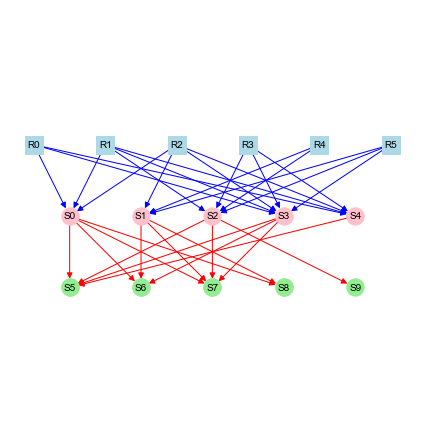

In [28]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random
from sympy import Poly, Symbol

from scipy.integrate import solve_ivp
from functools import partial
import time


#NR = proj_dim

NS_vec = [5,n_classes]
NS = sum(NS_vec)
input_nodes = [f'R{i}' for i in range(NR)]
target_nodes = [f'S{NS - n_classes + i}' for i in range(n_classes)]
print(target_nodes)
p_r = 0.0

species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, p_f = 0.6, include_reverse=False, include_uncatalyzed=True)

# expand reactions
# species_names, reaction_strings, L = expand_catalyzed_reactions(species_names, reaction_strings, L)

target_node_idxs = [species_names.index(node) for node in target_nodes]

visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, node_size=300,
    arrow_size=12,
    font_size=10,
    rad = 0,
    num_outputs = 5,
    flip_horizontal = True
)
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')


r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=42,
    species_names=species_names,
    force_reverse=True
)

# 1. Create the simulator
sim = ReactionNetworkSimulator(r_n)
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
sim.solve_conservation_laws()
rates_orig = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])


Starting CRN (graph) training: 100 batches, batch_size=20
Batch    0/100 | Loss: 3.3278 (avg: 3.3278) | Acc: 5.0% (avg: 5.0%) | log_ra:2.34e+00 | Rates: [8.57e-02, 2.04e+01]
Batch   10/100 | Loss: 1.4888 (avg: 1.9454) | Acc: 40.0% (avg: 17.3%) | log_ra:2.11e+00 | Rates: [7.96e-02, 1.34e+01]
Batch   20/100 | Loss: 1.3704 (avg: 1.7445) | Acc: 45.0% (avg: 24.0%) | log_ra:1.77e+00 | Rates: [5.14e-02, 1.47e+01]
Batch   30/100 | Loss: 0.9972 (avg: 1.5787) | Acc: 55.0% (avg: 30.5%) | log_ra:1.04e+00 | Rates: [3.04e-02, 3.03e+01]
Batch   40/100 | Loss: 0.8699 (avg: 1.4414) | Acc: 90.0% (avg: 38.7%) | log_ra:1.74e+00 | Rates: [2.01e-02, 4.20e+01]
Batch   50/100 | Loss: 0.5627 (avg: 1.3209) | Acc: 95.0% (avg: 46.7%) | log_ra:3.74e-01 | Rates: [1.38e-02, 4.39e+01]
Batch   60/100 | Loss: 0.6692 (avg: 1.2163) | Acc: 95.0% (avg: 53.5%) | log_ra:1.71e+00 | Rates: [1.04e-02, 5.11e+01]
Batch   70/100 | Loss: 0.4502 (avg: 1.1235) | Acc: 100.0% (avg: 59.2%) | log_ra:1.49e+00 | Rates: [7.55e-03, 6.25e+01]

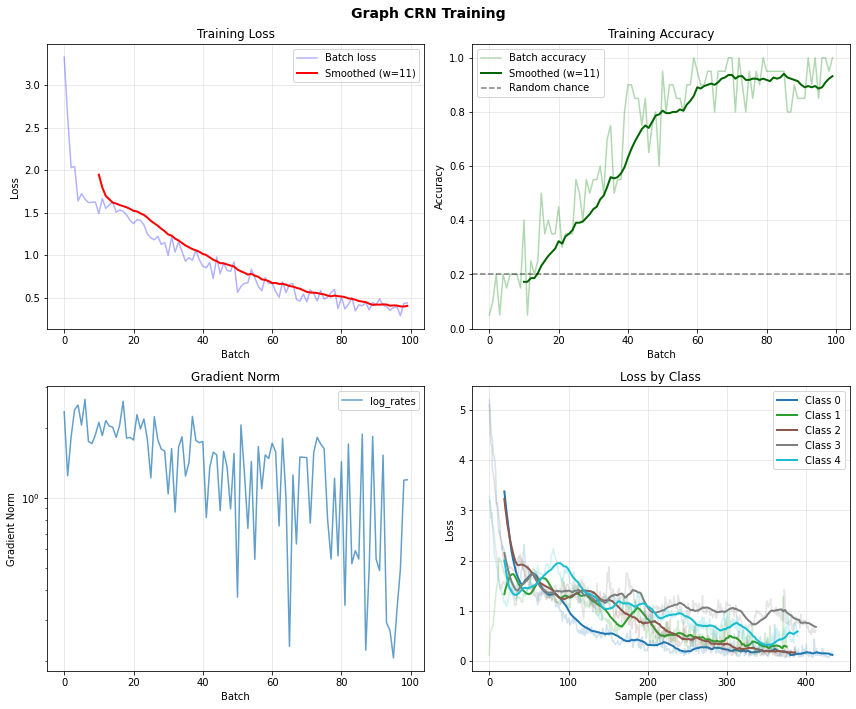

(<Figure size 864x720 with 4 Axes>,
 array([<Axes: title={'center': 'Training Loss'}, xlabel='Batch', ylabel='Loss'>,
        <Axes: title={'center': 'Training Accuracy'}, xlabel='Batch', ylabel='Accuracy'>,
        <Axes: title={'center': 'Gradient Norm'}, xlabel='Batch', ylabel='Gradient Norm'>,
        <Axes: title={'center': 'Loss by Class'}, xlabel='Sample (per class)', ylabel='Loss'>],
       dtype=object))

In [23]:
import numpy as np
from CRNs.training import GraphComputation, CRNModel, UnifiedTrainer, run_training_crn, plot_training_diagnostics

# ============== SETUP ==============
# Assumes already defined: 
#   r_n, sim, L, G, input_nodes, target_nodes, n_classes, input_data
#   dR_dC_func, dR_dk_func, dR_dl_func, generate_positive_initial_concentrations_nnls

# Initialize rates (log-normal)
n_rates = len(r_n.get_rates())
rates = np.exp(np.random.randn(n_rates) * 1.0)
r_n.update_rates(rates)

# ============== GRAPH COMPUTATION ==============
graph_comp = GraphComputation(G, input_nodes, target_nodes)
graph_comp.build_r_n_maps(r_n)

# Build l0 to match graph node ordering
n_nodes = len(graph_comp.nodes)
default_l0 = np.ones(n_nodes)

# Target node indices in species list
target_node_idxs = [r_n.species_names.index(node) for node in target_nodes]
n_inputs = len(input_nodes)

# ============== MODEL ==============
crn_model = CRNModel(
    r_n=r_n,
    sim=sim,
    L=L,
    class_ids=target_node_idxs,
    n_inputs=n_inputs,
    default_l0=default_l0,
    forward_method='graph',
    graph_comp=graph_comp,
    dR_dC_func=dR_dC_func,
    dR_dk_func=dR_dk_func,
    dR_dl_func=dR_dl_func,
    generate_init_func=generate_positive_initial_concentrations_nnls,
)

# ============== TRAINER ==============
trainer = UnifiedTrainer(
    crn_model,
    optimizer_type='adam',
    lr_dict={'log_rates': 0.01, 'log_l0': 0.01},
    max_grad_norm=50.0,
    frozen_params=['log_l0']
)

# ============== TRAIN ==============
history = run_training_crn(
    trainer=trainer,
    input_data=input_data,
    n_classes=n_classes,
    num_batches=100,
    batch_size=20,
    T_start=0.1,
    T_end=0.1,
    T_decay=0.99,
    noise_start=0.0,
    noise_end=0.0,
    noise_decay=0.99,
    print_every=10,
    
)

plot_training_diagnostics(history, title="Graph CRN Training")

In [5]:
16*60

960

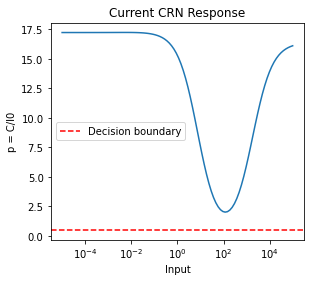

In [ ]:
from CRNs.training import (SimpleMLP, MLPModel, UnifiedTrainer, 
                           TrainingHistory, run_training, plot_training_diagnostics)

# Setup
mlp = SimpleMLP([NR, 6, n_classes], activation='tanh')
model = MLPModel(mlp, n_classes=n_classes)
trainer = UnifiedTrainer(model, lr=0.01, max_grad_norm=50.0)

# Run training in one line!
history = run_training(
    trainer=trainer,
    input_data=input_data,
    n_classes=n_classes,
    num_batches=100,
    batch_size=20,
    T_start=0.5, T_end=0.0, T_decay=0.99,
    noise_start=0.0, noise_end=0.0, noise_decay=0.9,
    print_every=50
)

# Plot results
plot_training_diagnostics(history, title="MLP Training", max_grad_norm=50.0, smoothing_window=1)

In [44]:
from CRNs import *
from CRNs.training import (
    GraphComputation, CRNModel, UnifiedTrainer, 
    run_training_crn_multitask, plot_training_diagnostics,
    generate_multitask_data, MultiTaskInputData
)
import numpy as np
import matplotlib.pyplot as plt
import random

# ============== PARAMETERS ==============
seed = 42
n_classes = 5
input_dim = 10
center_variance = 20.0
log_variance = 1
proj_dim = 5
NR = proj_dim
hidden_dim = 10
n_tasks = 4

np.random.seed(seed)
random.seed(seed)

Target nodes: ['S10', 'S11', 'S12', 'S13', 'S14']
Number of paths: [['R0', 'S0', 'S14'], ['R0', 'S1', 'S14'], ['R0', 'S2', 'S14'], ['R0', 'S3', 'S14'], ['R0', 'S4', 'S14'], ['R0', 'S5', 'S14'], ['R0', 'S6', 'S14'], ['R0', 'S7', 'S14'], ['R0', 'S8', 'S14'], ['R0', 'S9', 'S14']]


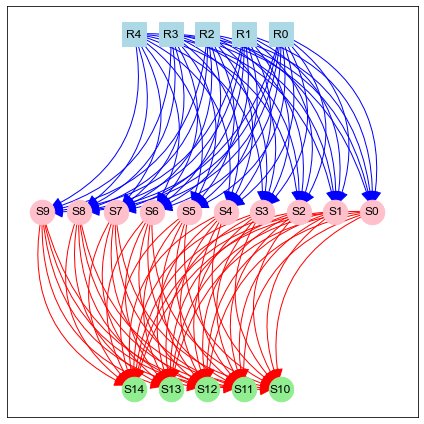

In [45]:
# ============== NETWORK STRUCTURE ==============
NS_vec = [hidden_dim, n_classes]
NS = sum(NS_vec)
input_nodes = [f'R{i}' for i in range(NR)]
target_nodes = [f'S{NS - n_classes + i}' for i in range(n_classes)]
print(f"Target nodes: {target_nodes}")
p_r = 0.0

species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = \
    generate_layered_feedforward_signaling_network(
        NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True
    )
target_node_idxs = [species_names.index(node) for node in target_nodes]

visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, num_outs=NS_vec[-1])
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')
print(f"Number of paths: {n_paths}")

# Create reaction network
r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=seed,
    species_names=species_names,
    force_reverse=True
)

# Create simulator and derivatives
sim = ReactionNetworkSimulator(r_n)
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
sim.solve_conservation_laws()

In [46]:
# ============== GRAPH COMPUTATION ==============
# Initialize rates
n_rates = len(r_n.get_rates())
rates = np.exp(np.random.randn(n_rates) * 1.0)
r_n.update_rates(rates)

graph_comp = GraphComputation(G, input_nodes, target_nodes)
graph_comp.build_r_n_maps(r_n)
n_nodes = len(graph_comp.nodes)
n_inputs = len(input_nodes)

# ============== GENERATE MULTI-TASK DATA ==============
multi_task_data = generate_multitask_data(
    n_tasks=n_tasks,
    n_classes=n_classes,
    n_samples_per_class=10000,
    input_dim=input_dim,
    proj_dim=proj_dim,
    center_variance=center_variance,
    log_variance=log_variance,
    center_offset=0.0,
    n_nodes=n_nodes,
    NR=NR,
    hidden_dim=hidden_dim,
    input_data_class=InputData,
    l0_log_mean=0.0,
    l0_log_std=3.0,
    base_seed=seed,
    permute_labels_only=True
)

print(f"Generated {multi_task_data.n_tasks} tasks")
for task_id in multi_task_data.task_ids:
    l0 = multi_task_data.get_l0(task_id)
    internal_l0 = l0[NR:NR+hidden_dim]
    print(f"  {task_id}: internal l0 = {internal_l0}")

Generated 4 tasks
  task_0: internal l0 = [  4.43772767   0.66047705   6.98011655  96.45625304   0.49536514
   0.49538954 114.16427804   9.99719134   0.24452856   5.09204812]
  task_1: internal l0 = [2.16452249e+00 6.55170871e-02 3.21258457e-01 2.00940427e-01
 1.31210792e+01 2.89665072e-01 4.45740052e+00 4.15963594e+02
 4.41938056e+01 2.67765262e-01]
  task_2: internal l0 = [1.05205032e-01 5.18871918e+01 4.20315315e+01 8.10927165e-03
 1.22230589e-02 5.82724251e-03 2.64106142e+02 1.30051967e+00
 8.54732616e-01 5.29315729e+00]
  task_3: internal l0 = [1.08233887e+00 2.18357863e+00 3.05612712e-01 5.41775963e-01
 2.20399632e-02 4.13589802e-04 2.38462704e+00 7.28091291e-02
 3.26160032e+00 1.65323097e+01]


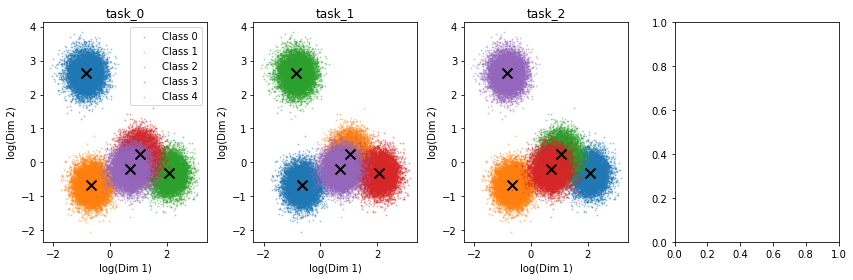

In [47]:
# ============== VISUALIZE TASK DATA ==============
fig, axes = plt.subplots(1, min(n_tasks, 4), figsize=(12, 4))
if n_tasks == 1:
    axes = [axes]

for i, task_id in enumerate(multi_task_data.task_ids[:3]):
    task = multi_task_data.get_task(task_id)
    data_list = [task['input_data'].data_list[c] for c in range(n_classes)]
    
    ax = axes[i]
    for c, class_data in enumerate(data_list):
        arr = np.vstack(class_data)
        ax.scatter(np.log(arr[:, 0]), np.log(arr[:, 1]), alpha=0.3, s=1, label=f'Class {c}')
    
    # Plot centers
    for lm in task['log_means']:
        ax.scatter(lm[0], lm[1], marker='x', s=100, c='black', linewidths=2)
    
    ax.set_xlabel('log(Dim 1)')
    ax.set_ylabel('log(Dim 2)')
    ax.set_title(f'{task_id}')
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

Trainable params: ['log_rates']
Starting CRN (graph) multi-task training: 500 batches, batch_size=20, n_tasks=4
Batch    0/500 | Loss: 2.9389 (avg: 2.9389) | Acc: 20.0% (avg: 20.0%) | log_ra:1.26e+00 | Rates: [3.70e-02, 4.51e+01]
Batch  100/500 | Loss: 0.5680 (avg: 1.0707) | Acc: 100.0% (avg: 64.5%) | log_ra:1.64e+00 | Rates: [8.32e-03, 1.81e+02]
Batch  200/500 | Loss: 0.3928 (avg: 0.4139) | Acc: 90.0% (avg: 93.9%) | log_ra:1.60e-01 | Rates: [2.50e-03, 2.42e+02]
Batch  300/500 | Loss: 0.2412 (avg: 0.2774) | Acc: 95.0% (avg: 96.8%) | log_ra:3.68e-01 | Rates: [7.93e-04, 3.29e+02]
Batch  400/500 | Loss: 0.1510 (avg: 0.2036) | Acc: 100.0% (avg: 98.1%) | log_ra:8.72e-01 | Rates: [2.93e-04, 4.40e+02]
Batch  499/500 | Loss: 0.2040 (avg: 0.1581) | Acc: 95.0% (avg: 99.0%) | log_ra:3.36e-01 | Rates: [1.23e-04, 5.18e+02]

Training Summary
Training time: 128.0 seconds
Final loss (last 100 batches): 0.1581
Min loss achieved: 0.0749
Final accuracy (last 100 batches): 99.0%
Best accuracy: 100.0%
Fina

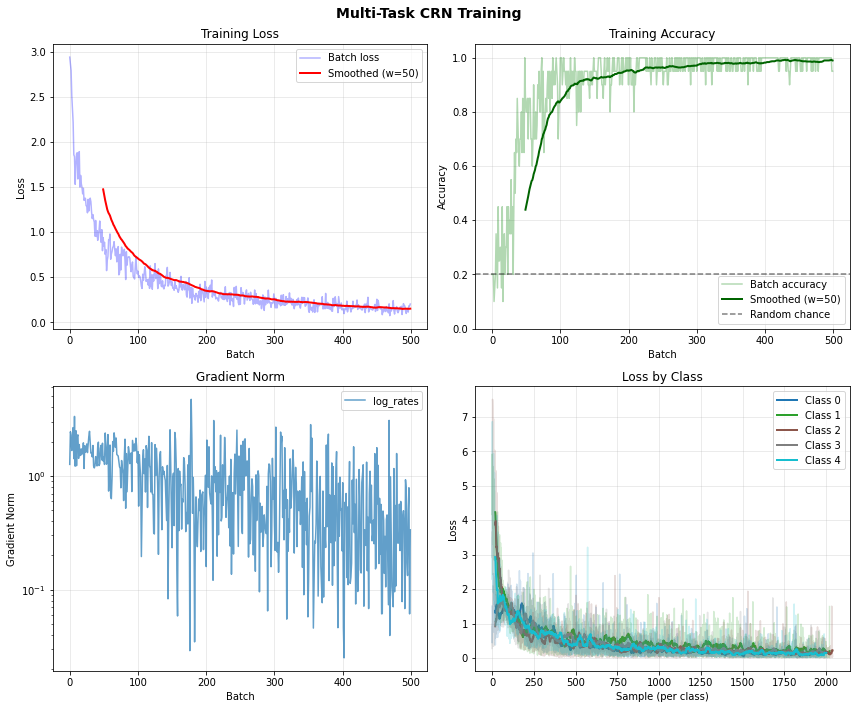

(<Figure size 864x720 with 4 Axes>,
 array([<Axes: title={'center': 'Training Loss'}, xlabel='Batch', ylabel='Loss'>,
        <Axes: title={'center': 'Training Accuracy'}, xlabel='Batch', ylabel='Accuracy'>,
        <Axes: title={'center': 'Gradient Norm'}, xlabel='Batch', ylabel='Gradient Norm'>,
        <Axes: title={'center': 'Loss by Class'}, xlabel='Sample (per class)', ylabel='Loss'>],
       dtype=object))

In [48]:
# ============== MODEL ==============
# Use first task's l0 as initial default (will be overwritten during training)
default_l0 = multi_task_data.get_l0(multi_task_data.task_ids[0]).copy()

crn_model = CRNModel(
    r_n=r_n,
    sim=sim,
    L=L,
    class_ids=target_node_idxs,
    n_inputs=n_inputs,
    default_l0=default_l0,
    forward_method='graph',
    graph_comp=graph_comp,
    dR_dC_func=dR_dC_func,
    dR_dk_func=dR_dk_func,
    dR_dl_func=dR_dl_func,
    generate_init_func=generate_positive_initial_concentrations_nnls,
)

# ============== TRAINER (with frozen l0) ==============
trainer = UnifiedTrainer(
    crn_model,
    optimizer_type='adam',
    # lr_dict={'log_rates': 0.001},
    lr_dict={'log_rates': 0.01},
    max_grad_norm=50.0,
    frozen_params=['log_l0']  # Freeze l0 - it's set per-task
)

print(f"Trainable params: {trainer.get_trainable_params()}")


# ============== TRAIN MULTI-TASK ==============
history = run_training_crn_multitask(
    trainer=trainer,
    multi_task_data=multi_task_data,
    n_classes=n_classes,
    num_batches=500,
    batch_size=20,
    T_start=0.1,
    T_end=0.1,
    T_decay=0.99,
    noise_start=0.0,
    noise_end=0.0,
    noise_decay=0.99,
    print_every=100,
    #debug_l0=True  # Enable debug output
)

plot_training_diagnostics(history, title="Multi-Task CRN Training")

In [ ]:
# ============== EVALUATE PER-TASK ==============
def evaluate_task(trainer, task_id, multi_task_data, n_samples=500, temperature=0.1):
    """Evaluate accuracy on a specific task."""
    # Set l0 for this task
    trainer.model._default_l0 = multi_task_data.get_l0(task_id).copy()
    
    correct = 0
    n_classes = multi_task_data.get_n_classes(task_id)
    
    for _ in range(n_samples):
        target_idx = random.randrange(n_classes)
        inputs = multi_task_data.get_next_training_sample(task_id, target_idx)
        
        outputs = trainer.model.forward(inputs)
        probs = trainer.softmax(outputs, temperature)
        
        if np.argmax(probs) == target_idx:
            correct += 1
    
    return correct / n_samples

print("Per-task accuracy:")
for task_id in multi_task_data.task_ids:
    acc = evaluate_task(trainer, task_id, multi_task_data, n_samples=500)
    print(f"  {task_id}: {acc:.1%}")

## sharpness

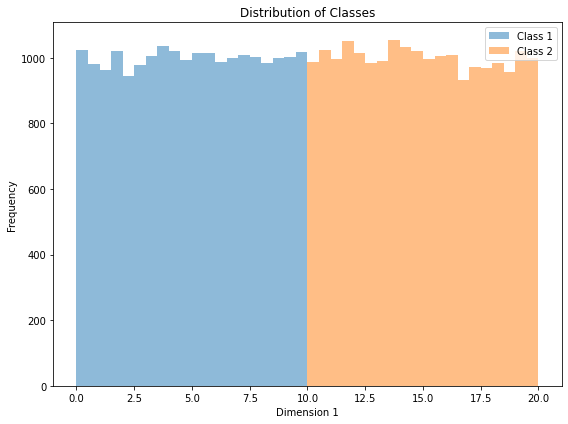

In [29]:
############################################################
################  Load classification data #################
############################################################

n_classes = 2

from CRNs.utils import InputData
import numpy as np
import matplotlib.pyplot as plt

# Parameters for uniform 1D data
n_samples = 20000
xm = 10.0   # upper bound for class 1; class 2 lives in [xm, 2*xm]

# Class 1: uniform in [0, xm]
dist_1 = np.random.uniform(0, xm, size=(n_samples, 1))

# Class 2: uniform in [xm, 2*xm]
dist_2 = np.random.uniform(xm, 2 * xm, size=(n_samples, 1))

# data_list: list of lists of samples per class (each sample as 1D array for InputData)
data_list = [[dist_1[i] for i in range(n_samples)], [dist_2[i] for i in range(n_samples)]]

input_data = InputData(n_classes, data_list)

# Plot
plt.figure(figsize=(8, 6))
all_x = np.concatenate([dist_1[:, 0], dist_2[:, 0]])
bin_width = 0.5
bins = np.arange(0, 2 * xm + bin_width, bin_width)
plt.hist(dist_1[:, 0], bins=bins, alpha=0.5, label='Class 1')
plt.hist(dist_2[:, 0], bins=bins, alpha=0.5, label='Class 2')
plt.xlabel('Dimension 1')
plt.ylabel('Frequency')
plt.title('Distribution of Classes')
plt.legend()
plt.tight_layout()
plt.show()

['S1', 'S2']


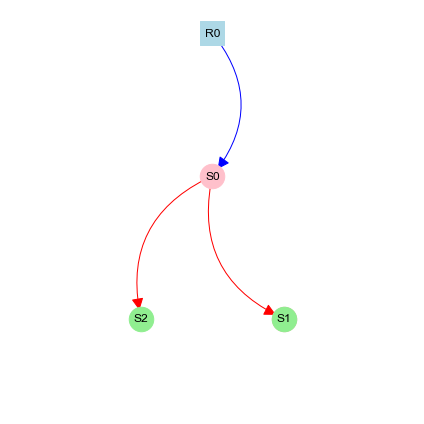

In [49]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random
from sympy import Poly, Symbol

from scipy.integrate import solve_ivp
from functools import partial
import time


proj_dim = 6
n_classes = 2
NR = proj_dim
seed = 42

NR = 1
NS_vec = [1,n_classes]
NS = sum(NS_vec)
input_nodes = [f'R{i}' for i in range(NR)]
target_nodes = [f'S{NS - n_classes + i}' for i in range(n_classes)]
print(target_nodes)
p_r = 0.0

species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)

#reaction_strings, adjacency_matrix = add_recurrent_connections(adjacency_matrix, reaction_strings, False, input_substrates_list, NR, NS, 1.0, seed=seed)    
# expand reactions
#species_names, reaction_strings, L = expand_catalyzed_reactions(species_names, reaction_strings, L)

target_node_idxs = [species_names.index(node) for node in target_nodes]

visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, num_outputs=NS_vec[-1])
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')


r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=42,
    species_names=species_names,
    force_reverse=True
)

# 1. Create the simulator
sim = ReactionNetworkSimulator(r_n)
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
sim.solve_conservation_laws()
rates_orig = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])


Starting CRN (graph) training: 250 batches, batch_size=50
Batch    0/250 | Loss: 0.7016 (avg: 0.7016) | Acc: 42.0% (avg: 42.0%) | log_ra:1.82e-01 | Rates: [2.01e-01, 1.43e+00]
Batch   10/250 | Loss: 0.6570 (avg: 0.6816) | Acc: 92.0% (avg: 61.8%) | log_ra:2.06e-01 | Rates: [3.30e-02, 5.17e+00]
Batch   20/250 | Loss: 0.6160 (avg: 0.6573) | Acc: 88.0% (avg: 71.1%) | log_ra:2.90e-01 | Rates: [7.43e-03, 9.30e+00]
Batch   30/250 | Loss: 0.5991 (avg: 0.6366) | Acc: 86.0% (avg: 77.9%) | log_ra:3.65e-01 | Rates: [2.64e-03, 1.09e+01]
Batch   40/250 | Loss: 0.5843 (avg: 0.6251) | Acc: 100.0% (avg: 80.3%) | log_ra:3.39e-01 | Rates: [1.33e-03, 1.33e+01]
Batch   50/250 | Loss: 0.5674 (avg: 0.6169) | Acc: 88.0% (avg: 81.3%) | log_ra:3.13e-01 | Rates: [7.72e-04, 1.48e+01]
Batch   60/250 | Loss: 0.5695 (avg: 0.6109) | Acc: 90.0% (avg: 82.2%) | log_ra:2.90e-01 | Rates: [4.71e-04, 1.74e+01]
Batch   70/250 | Loss: 0.5796 (avg: 0.6065) | Acc: 86.0% (avg: 82.8%) | log_ra:3.75e-01 | Rates: [3.09e-04, 1.94e+0

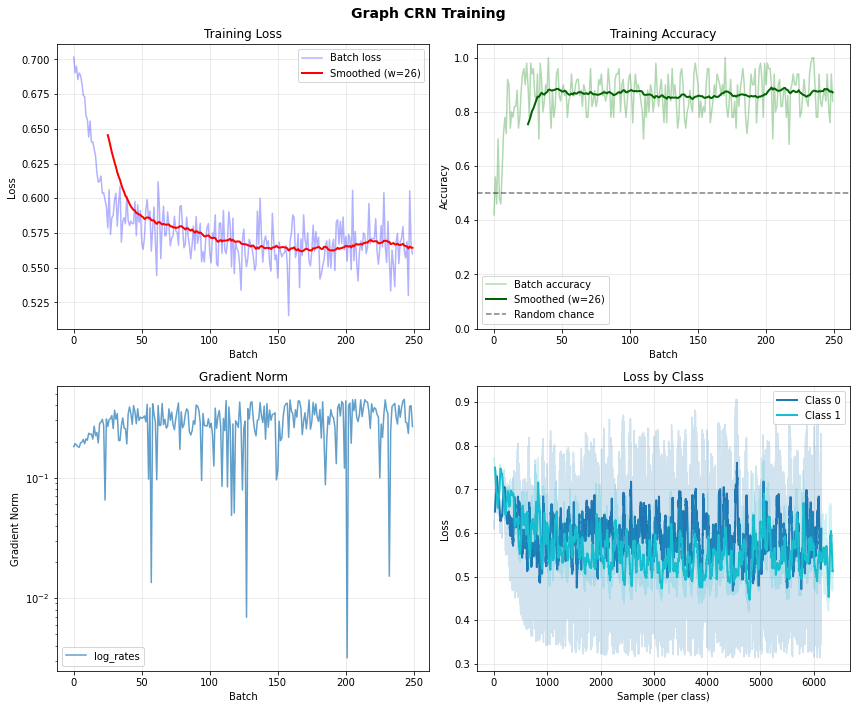

(<Figure size 864x720 with 4 Axes>,
 array([<Axes: title={'center': 'Training Loss'}, xlabel='Batch', ylabel='Loss'>,
        <Axes: title={'center': 'Training Accuracy'}, xlabel='Batch', ylabel='Accuracy'>,
        <Axes: title={'center': 'Gradient Norm'}, xlabel='Batch', ylabel='Gradient Norm'>,
        <Axes: title={'center': 'Loss by Class'}, xlabel='Sample (per class)', ylabel='Loss'>],
       dtype=object))

In [53]:
import numpy as np
from CRNs.training import GraphComputation, CRNModel, UnifiedTrainer, run_training_crn, plot_training_diagnostics

# ============== SETUP ==============
# Assumes already defined: 
#   r_n, sim, L, G, input_nodes, target_nodes, n_classes, input_data
#   dR_dC_func, dR_dk_func, dR_dl_func, generate_positive_initial_concentrations_nnls

# Initialize rates (log-normal)
n_rates = len(r_n.get_rates())
rates = np.exp(np.random.randn(n_rates) * 1.0)
r_n.update_rates(rates)

# ============== GRAPH COMPUTATION ==============
graph_comp = GraphComputation(G, input_nodes, target_nodes)
graph_comp.build_r_n_maps(r_n)

# Build l0 to match graph node ordering
n_nodes = len(graph_comp.nodes)
default_l0 = np.ones(n_nodes)

# Target node indices in species list
target_node_idxs = [r_n.species_names.index(node) for node in target_nodes]
n_inputs = len(input_nodes)

# ============== MODEL ==============
crn_model = CRNModel(
    r_n=r_n,
    sim=sim,
    L=L,
    class_ids=target_node_idxs,
    n_inputs=n_inputs,
    default_l0=default_l0,
    forward_method='graph',
    graph_comp=graph_comp,
    dR_dC_func=dR_dC_func,
    dR_dk_func=dR_dk_func,
    dR_dl_func=dR_dl_func,
    generate_init_func=generate_positive_initial_concentrations_nnls,
)

# ============== TRAINER ==============
trainer = UnifiedTrainer(
    crn_model,
    optimizer_type='adam',
    lr_dict={'log_rates': 0.01, 'log_l0': 0.01},
    max_grad_norm=50.0,
    frozen_params=['log_l0']
)

# ============== TRAIN ==============
history = run_training_crn(
    trainer=trainer,
    input_data=input_data,
    n_classes=n_classes,
    num_batches=250,
    batch_size=50,
    T_start=1,
    T_end=1,
    T_decay=0.99,
    noise_start=0.0,
    noise_end=0.0,
    noise_decay=0.99,
    print_every=10,
    
)

plot_training_diagnostics(history, title="Graph CRN Training")

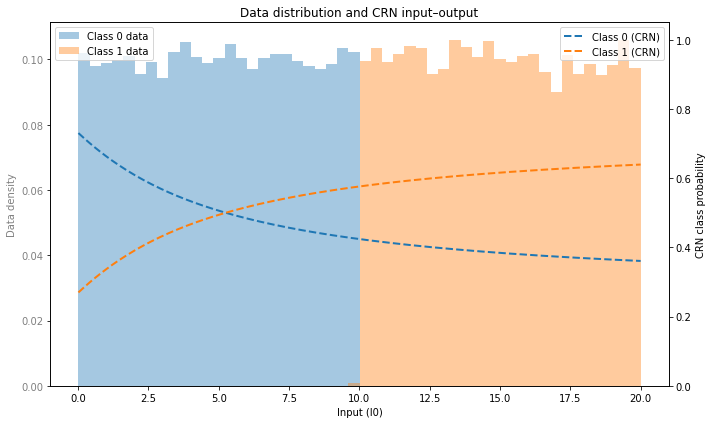

In [54]:
# ============== CRN response vs data distribution histogram ==============
import numpy as np
import matplotlib.pyplot as plt

n_l0 = 200
x_min_plot = 1e-2
x_max_plot = 2 * xm
l0_space = np.linspace(x_min_plot, x_max_plot, n_l0)
eval_temperature = 1.0

def softmax(x, temperature=1.0):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    e = np.exp(x / temperature)
    return e / e.sum()

prob_array_crn = np.zeros((n_classes, n_l0))
for i, l0_val in enumerate(l0_space):
    inputs = np.ones(n_inputs) * float(l0_val)
    class_outputs = crn_model.forward(inputs)
    probs = softmax(class_outputs, temperature=eval_temperature)
    prob_array_crn[:, i] = probs

# Single figure: histogram + CRN probability curves
fig, ax1 = plt.subplots(figsize=(10, 6), facecolor='white')

# Histogram of training data (density)
bin_width = (x_max_plot - x_min_plot) / 50
bins = np.arange(x_min_plot, x_max_plot + bin_width, bin_width)
ax1.hist(dist_1[:, 0], bins=bins, alpha=0.4, label='Class 0 data', color='C0', density=True)
ax1.hist(dist_2[:, 0], bins=bins, alpha=0.4, label='Class 1 data', color='C1', density=True)
ax1.set_xlabel('Input (l0)')
ax1.set_ylabel('Data density', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')
ax1.legend(loc='upper left')
ax1.set_ylim(bottom=0)

# CRN class probabilities on twin axis
ax2 = ax1.twinx()
for k in range(n_classes):
    ax2.plot(l0_space, prob_array_crn[k, :], label=f'Class {k} (CRN)', linewidth=2, color='C'+str(k), linestyle='--')
ax2.set_ylabel('CRN class probability', color='black')
ax2.set_ylim([0, 1.05])
ax2.legend(loc='upper right')
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Data distribution and CRN input–output')
plt.tight_layout()
plt.show()